# Almaty PM2.5 Exposure-Inequality: Complete Reproducible Pipeline

Full analysis pipeline for the source-aware PM2.5 exposure-inequality study of Almaty, Kazakhstan,
covering quality control, inequality indices, source attribution, spatial autocorrelation,
school-level exposure, QC sensitivity analysis, and a leakage-free predictive-modeling benchmark.

**Inputs (same folder):** `air_quality_data.csv` (146-station historical network), `city_twin_data.csv`
(25-station real-time context collector).

**Sections:** 1. QC pipeline · 2. Seasonal cycle & coverage · 3. Inequality indices · 4. WHO exceedance ·
5. Source attribution (distance, bearing, Figure 4) · 6. Traffic/congestion correlation ·
7. Spatial autocorrelation (Moran's I) · 8. School-level exposure (Table S4) ·
9. QC-parameter sensitivity (Table S3) · 10. Common-observation-window check (Table S2) ·
11. Regression benchmark (Table 4) · 12. Leakage-free classification benchmark (Table 6)


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

pd.set_option('display.width', 140)
DATA_DIR = '.'

aq = pd.read_csv(f'{DATA_DIR}/air_quality_data.csv', parse_dates=['datetime'])
twin = pd.read_csv(f'{DATA_DIR}/city_twin_data.csv', parse_dates=['timestamp_utc'])
CHP_LAT, CHP_LON = twin.loc[twin['station_id'] == 'chp', ['lat', 'lon']].iloc[0]

print('Historical network:', aq.shape, '| stations:', aq['location_id'].nunique())
print('Context collector:', twin.shape, '| stations:', twin['aq_id'].nunique())
print('CHP coordinates:', CHP_LAT, CHP_LON)


Historical network: (544943, 12) | stations: 146
Context collector: (16650, 40) | stations: 25
CHP coordinates: 43.29161 76.80437


## 1. Quality-control pipeline

In [2]:
def qc_pipeline(df, mad_mult=8, min_records=1000):
    step1 = df[(df['pm25'] > 0) & (df['pm25'] <= 500)].copy()
    def mad_keep(s):
        med = s.median(); mad = (s - med).abs().median()
        return s[(s - med).abs() <= mad_mult * 1.4826 * mad].index
    idx = []
    for loc, sub in step1.groupby('location_id'):
        idx.extend(mad_keep(sub['pm25']))
    step2 = step1.loc[idx]
    counts = step2.groupby('location_id').size()
    retained_ids = counts[counts >= min_records].index
    return step2[step2['location_id'].isin(retained_ids)].copy(), retained_ids

qc, retained_ids = qc_pipeline(aq)
print(f"Retained: {len(retained_ids)} stations, {len(qc):,} records "
      f"({len(qc)/len(aq)*100:.1f}% of {len(aq):,} raw)")


def daily_means(df, min_hours=18, tz_offset_h=5):
    """Daily station means in Almaty local time (UTC+5), keeping only station-days with >= min_hours hourly records."""
    d = df.copy()
    d['day'] = (d['datetime'].dt.tz_convert(None) + pd.Timedelta(hours=tz_offset_h)).dt.floor('D')
    g = d.groupby(['location_id', 'day'])['pm25'].agg(['mean', 'size'])
    return g.loc[g['size'] >= min_hours, 'mean']


Retained: 39 stations, 442,322 records (81.2% of 544,943 raw)


## 2. Seasonal cycle and per-station coverage

In [3]:
qc['month'] = qc['datetime'].dt.month
full_mean = qc.groupby('location_id')['pm25'].mean()
winter_mean = qc[qc['month'].isin([12, 1, 2])].groupby('location_id')['pm25'].mean()
summer_mean = qc[qc['month'].isin([6, 7, 8])].groupby('location_id')['pm25'].mean()

print(f"City-wide full-period mean (mean of 39 station means): {full_mean.mean():.1f} ug/m3")
print(f"Winter: {winter_mean.mean():.1f} | Summer: {summer_mean.mean():.1f} | "
      f"Ratio: {winter_mean.mean()/summer_mean.mean():.2f}x")
print(f"Station range: {full_mean.min():.2f}-{full_mean.max():.2f} "
      f"({full_mean.max()/full_mean.min():.1f}-fold)")


City-wide full-period mean (mean of 39 station means): 20.3 ug/m3
Winter: 36.9 | Summer: 14.7 | Ratio: 2.51x
Station range: 3.64-38.11 (10.5-fold)


## 3. Exposure-inequality indices (Table 1)

In [4]:
def gini(x):
    x = np.sort(np.asarray(x, dtype=float)); n = len(x); cum = np.cumsum(x)
    return (2*np.sum((np.arange(1, n+1))*x) - (n+1)*cum[-1]) / (n*cum[-1])

def theil(x):
    x = np.asarray(x, dtype=float); xbar = x.mean()
    return np.mean((x/xbar) * np.log(x/xbar))

def atkinson(x, eps):
    x = np.asarray(x, dtype=float); xbar = x.mean(); n = len(x)
    if eps == 1:
        return 1 - (np.prod(x)**(1/n)) / xbar
    return 1 - ((np.mean(x**(1-eps)))**(1/(1-eps))) / xbar

g = gini(full_mean.values)
t = theil(full_mean.values)
a05 = atkinson(full_mean.values, 0.5)
a10 = atkinson(full_mean.values, 1.0)
print(f"Station-level Gini: {g:.3f} | Theil: {t:.3f} | Atkinson(0.5): {a05:.3f} | Atkinson(1.0): {a10:.3f}")

station_days = daily_means(qc)  # local time (UTC+5), >=18 h/day completeness rule
d90, d10 = station_days.quantile(0.9), station_days.quantile(0.1)
print(f"(Not reported in manuscript) P90/P10 across station-days: {d90/d10:.2f}x -- Table 1 P90/P10 is computed across station means")


Station-level Gini: 0.210 | Theil: 0.074 | Atkinson(0.5): 0.038 | Atkinson(1.0): 0.080
(Not reported in manuscript) P90/P10 across station-days: 4.89x -- Table 1 P90/P10 is computed across station means


### 3b. Seasonally standardized (winter-only) inequality indices — PRIMARY

Adopted as the primary estimate in the manuscript (Table 1) to avoid conflating uneven temporal coverage across stations with genuine spatial heterogeneity (see Section 4.3 / Supplementary Table S2). Both minimum and maximum full-period station means anchoring the 'tenfold range' come from stations with zero winter coverage.

In [5]:
winter_only = winter_mean.dropna().values
print(f"Winter-only Gini (n={len(winter_only)}, primary): {gini(winter_only):.3f}")
print(f"Winter-only Theil: {theil(winter_only):.3f}")
print(f"Winter-only Atkinson(0.5): {atkinson(winter_only,0.5):.3f}")
print(f"Winter-only Atkinson(1.0): {atkinson(winter_only,1.0):.3f}")
print(f"Winter-only CoV: {winter_only.std(ddof=1)/winter_only.mean():.3f}")
print(f"Winter-only P90/P10: {np.percentile(winter_only,90)/np.percentile(winter_only,10):.2f}")
print(f"Winter-only P95/P5: {np.percentile(winter_only,95)/np.percentile(winter_only,5):.2f}")
print(f"Winter-only range: {winter_only.min():.1f}-{winter_only.max():.1f} ({winter_only.max()/winter_only.min():.1f}-fold)")

# check for the zero-winter-coverage confound (Round 2, Reviewer 3, Comment #2)
qc['is_winter'] = qc['month'].isin([12,1,2])
pct_winter_by_station = qc.groupby('location_id')['is_winter'].mean() * 100
rho_cov, p_cov = stats.spearmanr(pct_winter_by_station.reindex(full_mean.index), full_mean)
print(f"\n%% winter coverage range across 39 stations: {pct_winter_by_station.min():.1f}%-{pct_winter_by_station.max():.1f}%")
print(f"Spearman(%% winter coverage, full-period mean): rho={rho_cov:.3f}, p={p_cov:.3f}")


Winter-only Gini (n=36, primary): 0.197
Winter-only Theil: 0.063
Winter-only Atkinson(0.5): 0.033
Winter-only Atkinson(1.0): 0.068
Winter-only CoV: 0.350
Winter-only P90/P10: 2.40
Winter-only P95/P5: 3.09
Winter-only range: 11.3-60.3 (5.3-fold)

%% winter coverage range across 39 stations: 0.0%-31.3%
Spearman(%% winter coverage, full-period mean): rho=0.235, p=0.149


## 4. WHO 24-hour guideline exceedance

In [6]:
pct_days_above15 = (station_days > 15).mean() * 100
pct_days_above35 = (station_days > 35).mean() * 100
print(f"Station-days > 15 ug/m3 (24h guideline): {pct_days_above15:.1f}%")
print(f"Station-days > 35 ug/m3 (Interim Target-1): {pct_days_above35:.1f}%")

# completeness-rule audit and winter-only exceedance
_d = qc.copy()
_d['day'] = (_d['datetime'].dt.tz_convert(None) + pd.Timedelta(hours=5)).dt.floor('D')
_all_days = _d.groupby(['location_id', 'day']).size()
print(f"Station-days before completeness rule: {len(_all_days):,}; retained (>=18 h/day): {len(station_days):,} "
      f"({len(station_days)/len(_all_days)*100:.1f}%)")
_sd = station_days.reset_index()
_win = _sd[_sd['day'].dt.month.isin([12, 1, 2])]
print(f"Winter station-days > 15 ug/m3: {(_win['mean'] > 15).mean()*100:.1f}% (n={len(_win):,})")


Station-days > 15 ug/m3 (24h guideline): 48.3%
Station-days > 35 ug/m3 (Interim Target-1): 14.5%
Station-days before completeness rule: 19,628; retained (>=18 h/day): 18,035 (91.9%)
Winter station-days > 15 ug/m3: 86.6% (n=2,527)


## 5. Source attribution: distance, bearing, and Figure 4

In [7]:
def bearing(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1)*np.sin(lat2) - np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

meta = aq.drop_duplicates('location_id').set_index('location_id')[['lat', 'lon']]
stations = meta.loc[retained_ids].copy()
stations['bearing'] = bearing(CHP_LAT, CHP_LON, stations['lat'], stations['lon'])
stations['dist_km'] = haversine_km(CHP_LAT, CHP_LON, stations['lat'], stations['lon'])
stations['full_mean'] = full_mean
stations['winter_mean'] = winter_mean
stations['quadrant'] = np.where((stations['bearing'] >= 0) & (stations['bearing'] < 90), 'NE', 'Other')
stations['ne_quadrant'] = (stations['quadrant'] == 'NE').astype(int)

def sector4(b):
    if 0 <= b < 90: return 'N-E'
    if 90 <= b < 180: return 'E-S'
    if 180 <= b < 270: return 'S-W'
    return 'W-N'
stations['sector4'] = stations['bearing'].apply(sector4)
stations.to_csv('stations_with_geometry.csv')

w = stations.dropna(subset=['winter_mean'])
ne, other = w[w['quadrant']=='NE']['winter_mean'], w[w['quadrant']=='Other']['winter_mean']
u, p_dir = stats.mannwhitneyu(ne, other)
rho, p_dist = stats.spearmanr(w['dist_km'], w['winter_mean'])
print(f"NE quadrant (n={len(ne)}, mean={ne.mean():.1f}) vs Other (n={len(other)}, mean={other.mean():.1f}): "
      f"Mann-Whitney p={p_dir:.4f}")
print(f"Distance vs winter PM2.5: Spearman rho={rho:.3f}, p={p_dist:.3f}")


NE quadrant (n=13, mean=42.7) vs Other (n=23, mean=33.6): Mann-Whitney p=0.0561
Distance vs winter PM2.5: Spearman rho=-0.064, p=0.713


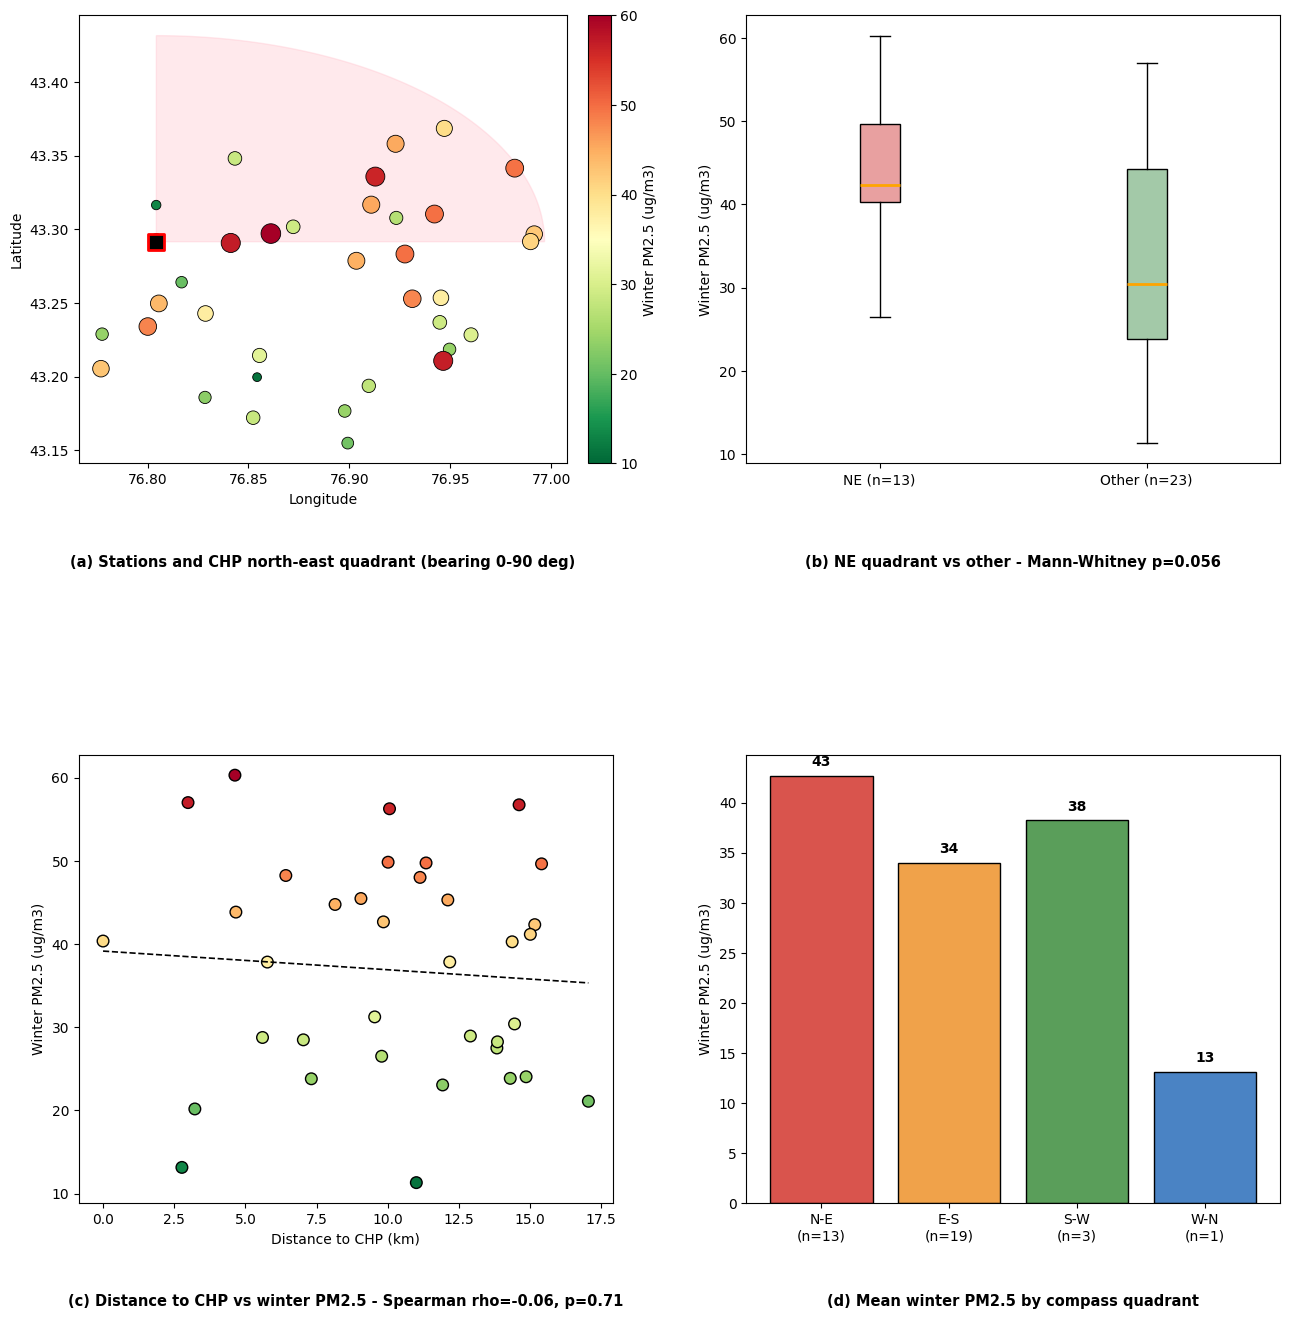

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
cmap = plt.cm.RdYlGn_r
norm = mcolors.Normalize(vmin=10, vmax=60)

ax = axes[0, 0]
plot_df = stations.dropna(subset=['winter_mean'])
sizes = 40 + (plot_df['winter_mean']-plot_df['winter_mean'].min())/(plot_df['winter_mean'].max()-plot_df['winter_mean'].min())*160
sc = ax.scatter(plot_df['lon'], plot_df['lat'], c=plot_df['winter_mean'], cmap=cmap, norm=norm,
                 s=sizes, edgecolor='black', linewidth=0.6, zorder=3)
R = 0.14
b = np.linspace(0, 90, 100); theta_std = np.radians(90 - b)
wedge_lon = CHP_LON + R*np.cos(theta_std)/np.cos(np.radians(CHP_LAT))
wedge_lat = CHP_LAT + R*np.sin(theta_std)
ax.fill(np.concatenate([[CHP_LON], wedge_lon, [CHP_LON]]),
        np.concatenate([[CHP_LAT], wedge_lat, [CHP_LAT]]), color='pink', alpha=0.35, zorder=1)
ax.scatter([CHP_LON], [CHP_LAT], marker='s', s=140, color='black', edgecolor='red', linewidth=2, zorder=4)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04).set_label('Winter PM2.5 (ug/m3)')

ax = axes[0, 1]
bp = ax.boxplot([ne.values, other.values], tick_labels=[f'NE (n={len(ne)})', f'Other (n={len(other)})'],
                patch_artist=True, medianprops=dict(color='orange', linewidth=2))
bp['boxes'][0].set_facecolor('#e8a0a0'); bp['boxes'][1].set_facecolor('#a3c9a8')
ax.set_ylabel('Winter PM2.5 (ug/m3)')

ax = axes[1, 0]
ax.scatter(w['dist_km'], w['winter_mean'], c=w['winter_mean'], cmap=cmap, norm=norm, s=70, edgecolor='black')
zz = np.polyfit(w['dist_km'], w['winter_mean'], 1); xx = np.linspace(0, w['dist_km'].max(), 50)
ax.plot(xx, np.polyval(zz, xx), 'k--', linewidth=1.2)
ax.set_xlabel('Distance to CHP (km)'); ax.set_ylabel('Winter PM2.5 (ug/m3)')

ax = axes[1, 1]
sector_order = ['N-E', 'E-S', 'S-W', 'W-N']
sm = w.groupby('sector4')['winter_mean'].mean().reindex(sector_order)
sn = w.groupby('sector4').size().reindex(sector_order)
bars = ax.bar([f'{s}\n(n={n})' for s, n in zip(sector_order, sn)], sm.values,
              color=['#d9544d','#f0a24a','#5a9e5a','#4a83c4'], edgecolor='black')
for bar, val in zip(bars, sm.values):
    ax.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.0f}', ha='center', fontweight='bold')
ax.set_ylabel('Winter PM2.5 (ug/m3)')

plt.tight_layout(rect=[0, 0.03, 1, 1]); plt.subplots_adjust(hspace=0.65, wspace=0.25)
captions = {(0,0): "(a) Stations and CHP north-east quadrant (bearing 0-90 deg)",
            (0,1): f"(b) NE quadrant vs other - Mann-Whitney p={p_dir:.3f}",
            (1,0): f"(c) Distance to CHP vs winter PM2.5 - Spearman rho={rho:.2f}, p={p_dist:.2f}",
            (1,1): "(d) Mean winter PM2.5 by compass quadrant"}
for (row, col), txt in captions.items():
    pos = axes[row, col].get_position()
    fig.text((pos.x0+pos.x1)/2, pos.y0-0.07, txt, ha='center', va='top', fontsize=10.5, fontweight='bold')
plt.savefig('figure4_source_attribution.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Traffic and congestion correlation (context layer, n = 25)

In [9]:
station_traffic = twin.groupby('aq_id').agg(cars_per_hour=('cars_per_hour', 'mean'),
                                             congestion_percent=('congestion_percent', 'mean')).reset_index()
merged = stations.reset_index().merge(station_traffic, left_on='location_id', right_on='aq_id', how='inner')
for col in ['cars_per_hour', 'congestion_percent']:
    rho_t, p_t = stats.spearmanr(merged[col], merged['winter_mean'])
    print(f"{col} vs winter PM2.5: rho={rho_t:.3f}, p={p_t:.3f}, n={len(merged)}")


cars_per_hour vs winter PM2.5: rho=0.248, p=0.233, n=25
congestion_percent vs winter PM2.5: rho=0.225, p=0.279, n=25


## 7. Spatial autocorrelation (Moran's I)

In [10]:
from libpysal.weights import KNN
from esda.moran import Moran

np.random.seed(42)
w_sub = stations.dropna(subset=['winter_mean'])
from pyproj import Transformer
_tr = Transformer.from_crs('EPSG:4326', 'EPSG:32643', always_xy=True)  # UTM 43N, metres
coords = np.column_stack(_tr.transform(w_sub['lon'].values, w_sub['lat'].values))

for k in [4, 6, 8]:
    wk = KNN.from_array(coords, k=k); wk.transform = 'r'
    mi_full = Moran(w_sub['full_mean'].values, wk, permutations=9999)
    mi_win = Moran(w_sub['winter_mean'].values, wk, permutations=9999)
    print(f"k={k}: full-period Moran's I={mi_full.I:.3f} (p={mi_full.p_sim:.4f}) | "
          f"winter Moran's I={mi_win.I:.3f} (p={mi_win.p_sim:.4f})")


k=4: full-period Moran's I=0.282 (p=0.0047) | winter Moran's I=0.145 (p=0.0639)
k=6: full-period Moran's I=0.220 (p=0.0057) | winter Moran's I=0.127 (p=0.0441)


k=8: full-period Moran's I=0.203 (p=0.0037) | winter Moran's I=0.091 (p=0.0616)


## 8. School-level exposure (Table S4)

In [11]:
names = aq.drop_duplicates('location_id')[['location_id', 'name', 'lat', 'lon']]
schools = names[names['name'].str.contains('school', case=False, na=False)].set_index('location_id')
schools['winter_pm25'] = winter_mean.reindex(schools.index)
schools = schools.dropna(subset=['winter_pm25'])
schools['bearing'] = bearing(CHP_LAT, CHP_LON, schools['lat'], schools['lon'])
schools['ne_quadrant'] = schools['bearing'].apply(lambda b: 'Yes' if 0 <= b < 90 else 'No')

# Administrative districts identified via open-source lookup (institutional registries,
# job/procurement postings) -- see Supplementary Materials Table S4 for sources.
district_lookup = {
    '169 School': 'Alatau', 'School 160': 'Alatau', 'School 137': 'Zhetysu',
    'School 192': 'Nauryzbay', 'School 77': 'Medeu', 'School 187': 'Bostandyk',
    'School 190': 'Bostandyk', 'School 175': 'Auezov',
}
schools['administrative_district'] = schools['name'].map(district_lookup)
schools = schools.sort_values('winter_pm25', ascending=False)
print(schools[['name', 'winter_pm25', 'ne_quadrant', 'administrative_district']].to_string())
schools.to_csv('table_s4_schools.csv')


                   name  winter_pm25 ne_quadrant administrative_district
location_id                                                             
2812691      169 School    60.297048         Yes                  Alatau
2812821      School 160    56.259218         Yes                  Alatau
2812563      School 137    45.466077         Yes                 Zhetysu
2812775      School 192    28.234821          No               Nauryzbay
2812751       School 77    23.845215          No                   Medeu
2812690      School 187    23.052416          No               Bostandyk
2812753      School 190    21.092017          No               Bostandyk
2812756      School 175    11.309555          No                  Auezov


## 9. QC-parameter sensitivity analysis (Table S3)

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

ctx_traffic = twin.groupby('aq_id').agg(cars_per_hour=('cars_per_hour','mean'),
                                         congestion_percent=('congestion_percent','mean'))
twin_ids = set(twin['aq_id'].unique())

def run_qc_variant(mad_mult, min_records):
    qc_v, retained_v = qc_pipeline(aq, mad_mult, min_records)
    full_v = qc_v.groupby('location_id')['pm25'].mean()
    g_v = gini(full_v.values)
    daily_v = daily_means(qc_v)
    pct_v = (daily_v > 15).mean() * 100

    qc_v = qc_v.copy(); qc_v['month'] = qc_v['datetime'].dt.month
    winter_v = qc_v[qc_v['month'].isin([12,1,2])].groupby('location_id')['pm25'].mean()
    cls_ids = [i for i in retained_v if i in twin_ids and i in winter_v.index]
    if len(cls_ids) < 5:
        return dict(mad=mad_mult, min_rec=min_records, n_stations=len(retained_v),
                     n_records=len(qc_v), gini=round(g_v,3), pct_exceed=round(pct_v,1), nb_acc=np.nan)

    dfc = meta.loc[cls_ids].copy()
    dfc['bearing'] = bearing(CHP_LAT, CHP_LON, dfc['lat'], dfc['lon'])
    dfc['dist_km'] = haversine_km(CHP_LAT, CHP_LON, dfc['lat'], dfc['lon'])
    dfc['ne_quadrant'] = ((dfc['bearing']>=0)&(dfc['bearing']<90)).astype(int)
    dfc = dfc.join(ctx_traffic, how='inner').join(winter_v.rename('winter_pm25'), how='inner')
    n = len(dfc); feats = ['dist_km','ne_quadrant','cars_per_hour','congestion_percent']
    yt, yp = [], []
    for ti in range(n):
        tri = [i for i in range(n) if i != ti]
        Xtr, Xte = dfc.iloc[tri][feats].values, dfc.iloc[ti:ti+1][feats].values
        ytr_reg = dfc.iloc[tri]['winter_pm25'].values
        thr = np.median(ytr_reg); ytr = (ytr_reg > thr).astype(int)
        yte = int(dfc.iloc[ti]['winter_pm25'] > thr)
        if len(np.unique(ytr)) < 2:
            pred = ytr[0]
        else:
            sc = StandardScaler().fit(Xtr)
            m = GaussianNB().fit(sc.transform(Xtr), ytr)
            pred = m.predict(sc.transform(Xte))[0]
        yt.append(yte); yp.append(pred)
    acc = np.mean(np.array(yt) == np.array(yp))
    return dict(mad=mad_mult, min_rec=min_records, n_stations=len(retained_v), n_records=len(qc_v),
                gini=round(g_v,3), pct_exceed=round(pct_v,1), nb_acc=round(acc,2))

sensitivity_results = []
for mad_mult in [3, 5, 8]:
    for min_rec in [500, 1000, 2000]:
        r = run_qc_variant(mad_mult, min_rec)
        sensitivity_results.append(r); print(r)
pd.DataFrame(sensitivity_results).to_csv('table_s3_sensitivity.csv', index=False)


{'mad': 3, 'min_rec': 500, 'n_stations': 41, 'n_records': 404903, 'gini': np.float64(0.29), 'pct_exceed': np.float64(39.7), 'nb_acc': np.float64(0.8)}


{'mad': 3, 'min_rec': 1000, 'n_stations': 39, 'n_records': 403644, 'gini': np.float64(0.228), 'pct_exceed': np.float64(39.5), 'nb_acc': np.float64(0.8)}


{'mad': 3, 'min_rec': 2000, 'n_stations': 38, 'n_records': 402387, 'gini': np.float64(0.213), 'pct_exceed': np.float64(39.6), 'nb_acc': np.float64(0.8)}


{'mad': 5, 'min_rec': 500, 'n_stations': 41, 'n_records': 427328, 'gini': np.float64(0.278), 'pct_exceed': np.float64(44.9), 'nb_acc': np.float64(0.8)}


{'mad': 5, 'min_rec': 1000, 'n_stations': 39, 'n_records': 426016, 'gini': np.float64(0.217), 'pct_exceed': np.float64(44.7), 'nb_acc': np.float64(0.8)}


{'mad': 5, 'min_rec': 2000, 'n_stations': 38, 'n_records': 424660, 'gini': np.float64(0.202), 'pct_exceed': np.float64(44.9), 'nb_acc': np.float64(0.8)}


{'mad': 8, 'min_rec': 500, 'n_stations': 42, 'n_records': 444172, 'gini': np.float64(0.283), 'pct_exceed': np.float64(48.4), 'nb_acc': np.float64(0.72)}


{'mad': 8, 'min_rec': 1000, 'n_stations': 39, 'n_records': 442322, 'gini': np.float64(0.21), 'pct_exceed': np.float64(48.3), 'nb_acc': np.float64(0.72)}


{'mad': 8, 'min_rec': 2000, 'n_stations': 38, 'n_records': 440904, 'gini': np.float64(0.195), 'pct_exceed': np.float64(48.4), 'nb_acc': np.float64(0.72)}


## 10. Common-observation-window check (Table S2)

In [13]:
ranges = qc.groupby('location_id')['datetime'].agg(['min', 'max'])
active = list(retained_ids)
while True:
    r = ranges.loc[active]
    cs, ce = r['min'].max(), r['max'].min()
    if ce > cs:
        break
    worst_end, worst_start = r['max'].idxmin(), r['min'].idxmax()
    if r.loc[worst_end,'max'] < r.loc[worst_start,'min']:
        active.remove(worst_end if r['max'].sort_values().iloc[1]-r.loc[worst_end,'max']
                      > r.loc[worst_start,'min']-r['min'].sort_values(ascending=False).iloc[1] else worst_start)
    else:
        active.remove(worst_end)

print(f"Common window after excluding {len(retained_ids)-len(active)} stations, {len(active)} remain: {cs} to {ce}")
common = qc[(qc['location_id'].isin(active)) & (qc['datetime']>=cs) & (qc['datetime']<=ce)]
full_common = common.groupby('location_id')['pm25'].mean()
g_common = gini(full_common.values)
daily_common = daily_means(common)
pct_common = (daily_common > 15).mean() * 100
print(f"Common-window Gini: {g_common:.3f} (full-period baseline: {g:.3f})")
print(f"Common-window WHO exceedance: {pct_common:.1f}% (full-period baseline: {pct_days_above15:.1f}%)")


Common window after excluding 3 stations, 36 remain: 2024-11-08 17:00:00+00:00 to 2024-12-05 09:00:00+00:00
Common-window Gini: 0.171 (full-period baseline: 0.210)
Common-window WHO exceedance: 91.3% (full-period baseline: 48.3%)


## 11. Regression benchmark (Table 4)

Predicting station-mean PM2.5 from source features under leave-one-station-out CV.

In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

modeling_sample = merged.copy()
modeling_sample['ne_quadrant'] = (modeling_sample['quadrant'] == 'NE').astype(int)
reg_features = ['dist_km', 'ne_quadrant', 'cars_per_hour', 'congestion_percent']
Xr, yr = modeling_sample[reg_features].values, modeling_sample['winter_mean'].values
n = len(modeling_sample)
reg_models = {
    'Linear regression': lambda: LinearRegression(),
    'Ridge (alpha=1)': lambda: Ridge(alpha=1.0),
    'Lasso (alpha=1)': lambda: Lasso(alpha=1.0),
    'Random forest': lambda: RandomForestRegressor(n_estimators=200, max_depth=3, random_state=42),
}
print(f"{'Model':<20}{'R2 (LOSO)':<12}{'MAE (ug/m3)'}")
for name, fn in reg_models.items():
    preds = []
    for ti in range(n):
        tri = [i for i in range(n) if i != ti]
        sc = StandardScaler().fit(Xr[tri])
        preds.append(fn().fit(sc.transform(Xr[tri]), yr[tri]).predict(sc.transform(Xr[ti:ti+1]))[0])
    print(f"{name:<20}{r2_score(yr, preds):<+12.2f}{mean_absolute_error(yr, preds):.1f}")


Model               R2 (LOSO)   MAE (ug/m3)
Linear regression   -0.06       10.7
Ridge (alpha=1)     -0.02       10.5
Lasso (alpha=1)     +0.10       10.1


Random forest       -0.29       12.2


## 12. Leakage-free classification benchmark (Table 6)

Threshold, feature scaling, and hyperparameter selection are confined exclusively to each
training fold under leave-one-station-out cross-validation.

In [15]:
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score
from sklearn.model_selection import LeaveOneOut
from statsmodels.stats.contingency_tables import mcnemar

np.random.seed(42)
cls_features = ['dist_km', 'ne_quadrant', 'cars_per_hour', 'congestion_percent']
Xc_all = modeling_sample[cls_features].values
yc_reg_all = modeling_sample['winter_mean'].values
n = len(modeling_sample)

def inner_select_k(Xtr, ytr):
    candidates = [k for k in [3,5,7] if k < len(Xtr)]
    best_k, best_acc = candidates[0], -1
    loo = LeaveOneOut()
    for k in candidates:
        preds = [KNeighborsClassifier(n_neighbors=k).fit(Xtr[tr], ytr[tr]).predict(Xtr[val])[0]
                 for tr, val in loo.split(Xtr)]
        acc = np.mean(np.array(preds) == ytr)
        if acc > best_acc: best_acc, best_k = acc, k
    return best_k

def inner_select_C(Xtr, ytr):
    candidates = [0.01, 0.1, 1, 10]
    best_C, best_acc = candidates[0], -1
    loo = LeaveOneOut()
    for C in candidates:
        preds = [LogisticRegression(C=C, max_iter=1000).fit(Xtr[tr], ytr[tr]).predict(Xtr[val])[0]
                 for tr, val in loo.split(Xtr)]
        acc = np.mean(np.array(preds) == ytr)
        if acc > best_acc: best_acc, best_C = acc, C
    return best_C

fold_data = []
results = {m: {'y_true':[], 'y_pred':[]} for m in
           ['Majority-class baseline','Logistic regression','Naive Bayes','k-NN','Ridge classifier',
            'Random Forest','Interpretable rule (NE quadrant)']}

for ti in range(n):
    tri = [i for i in range(n) if i != ti]
    Xtr_raw, Xte_raw = Xc_all[tri], Xc_all[ti:ti+1]
    ytr_reg = yc_reg_all[tri]
    thresh = np.median(ytr_reg)
    ytr_cls = (ytr_reg > thresh).astype(int)
    yte_cls = int(yc_reg_all[ti] > thresh)
    scaler = StandardScaler().fit(Xtr_raw)
    Xtr, Xte = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)
    p1_train = ytr_cls.mean()
    fold_data.append({'y_true': yte_cls, 'p1_train': p1_train})

    maj = int(p1_train > 0.5)
    results['Majority-class baseline']['y_true'].append(yte_cls); results['Majority-class baseline']['y_pred'].append(maj)

    if len(np.unique(ytr_cls)) > 1:
        C = inner_select_C(Xtr, ytr_cls)
        pred = LogisticRegression(C=C, max_iter=1000).fit(Xtr, ytr_cls).predict(Xte)[0]
    else:
        pred = ytr_cls[0]
    results['Logistic regression']['y_true'].append(yte_cls); results['Logistic regression']['y_pred'].append(pred)

    m = GaussianNB().fit(Xtr, ytr_cls)
    results['Naive Bayes']['y_true'].append(yte_cls); results['Naive Bayes']['y_pred'].append(m.predict(Xte)[0])

    k = inner_select_k(Xtr, ytr_cls)
    m = KNeighborsClassifier(n_neighbors=k).fit(Xtr, ytr_cls)
    results['k-NN']['y_true'].append(yte_cls); results['k-NN']['y_pred'].append(m.predict(Xte)[0])

    m = RidgeClassifier().fit(Xtr, ytr_cls)
    results['Ridge classifier']['y_true'].append(yte_cls); results['Ridge classifier']['y_pred'].append(m.predict(Xte)[0])

    m = RandomForestClassifier(n_estimators=200, max_depth=3, random_state=42).fit(Xtr, ytr_cls)
    results['Random Forest']['y_true'].append(yte_cls); results['Random Forest']['y_pred'].append(m.predict(Xte)[0])

    pred_rule = int(modeling_sample.iloc[ti]['ne_quadrant'])
    results['Interpretable rule (NE quadrant)']['y_true'].append(yte_cls); results['Interpretable rule (NE quadrant)']['y_pred'].append(pred_rule)

y_true_all = np.array([f['y_true'] for f in fold_data])
p1_trains = np.array([f['p1_train'] for f in fold_data])

# CORRECTED prevalence-weighted baseline: 20,000 simulations (not a single realisation)
N_SIM = 20000
sim_accs = np.zeros(N_SIM)
for s in range(N_SIM):
    preds = (np.random.rand(n) < p1_trains).astype(int)
    sim_accs[s] = np.mean(preds == y_true_all)
baseline_mean = sim_accs.mean()
baseline_ci = np.percentile(sim_accs, [2.5, 97.5])
print(f"CORRECTED prevalence-weighted baseline ({N_SIM} simulations): "
      f"mean={baseline_mean:.3f}, 95%% interval=[{baseline_ci[0]:.2f},{baseline_ci[1]:.2f}]")
print(f"(Analytical expectation: {np.mean(p1_trains**2+(1-p1_trains)**2):.4f} -- matches simulation)")

def bootstrap_ci(y_true, y_pred, n_boot=2000):
    y_true, y_pred = np.array(y_true), np.array(y_pred); nn=len(y_true); accs=[]
    for _ in range(n_boot):
        idx = np.random.choice(nn, nn, replace=True)
        accs.append(np.mean(y_true[idx]==y_pred[idx]))
    return np.percentile(accs, [2.5, 97.5])

n_models_tested = len(results)  # 7: majority baseline + 6 classifiers, all compared vs prevalence baseline
bonferroni_alpha = 0.05 / n_models_tested
print(f"\nBonferroni-corrected threshold for {n_models_tested} models: {bonferroni_alpha:.4f}\n")

print(f"{'Model':<32}{'Acc':<7}{'95% CI':<15}{'F1':<6}{'BalAcc':<8}{'Sens':<6}{'Spec':<6}{'p_vs_baseline':<14}{'Bonferroni'}")
table_rows, cms = [], {}
for name, d in results.items():
    yt, yp = np.array(d['y_true']), np.array(d['y_pred'])
    acc = np.mean(yt==yp); ci = bootstrap_ci(yt, yp)
    f1 = f1_score(yt, yp, zero_division=0); bal = balanced_accuracy_score(yt, yp)
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0,1]).ravel()
    sens = tp/(tp+fn) if (tp+fn)>0 else float('nan')
    spec = tn/(tn+fp) if (tn+fp)>0 else float('nan')
    p_val = (np.sum(sim_accs >= acc) + 1) / (N_SIM + 1)  # smoothed Monte Carlo p
    survives = 'survives' if p_val < bonferroni_alpha else 'n.s.'
    print(f"{name:<32}{acc:<7.2f}[{ci[0]:.2f},{ci[1]:.2f}]  {f1:<6.2f}{bal:<8.2f}{sens:<6.2f}{spec:<6.2f}{p_val:<14.4f}{survives}")
    table_rows.append([name, acc, ci[0], ci[1], f1, bal, sens, spec, tn, fp, fn, tp, p_val])
    cms[name] = (tn, fp, fn, tp)

pd.DataFrame(table_rows, columns=['model','accuracy','ci_low','ci_high','f1','balanced_acc',
             'sensitivity','specificity','tn','fp','fn','tp','p_vs_random_baseline']).to_csv('table5_final.csv', index=False)

print("\n=== McNemar's paired test vs. majority-class baseline ===")
maj_pred = np.array(results['Majority-class baseline']['y_pred'])
for name in ['Logistic regression','Naive Bayes','k-NN','Ridge classifier','Random Forest']:
    pred = np.array(results[name]['y_pred'])
    correct_maj = (maj_pred==y_true_all).astype(int)
    correct_model = (pred==y_true_all).astype(int)
    b = np.sum((correct_maj==1)&(correct_model==0))
    c = np.sum((correct_maj==0)&(correct_model==1))
    table = [[np.sum((correct_maj==1)&(correct_model==1)), b],[c, np.sum((correct_maj==0)&(correct_model==0))]]
    res = mcnemar(table, exact=True)
    print(f"{name:<22} vs majority baseline: McNemar p={res.pvalue:.4f} (b={b}, c={c})")

print("\nNote: no model's 95% CI excludes both baselines; naive Bayes is nominally significant against")
print("the simulated random baseline (uncorrected) but does not survive Bonferroni correction across")
print("the seven models tested, consistent with the conclusion that apparent classification success on")
print("this network is not statistically distinguishable from chance once multiple comparisons are")
print("accounted for (see manuscript Section 3.4 and Table 5).")


CORRECTED prevalence-weighted baseline (20000 simulations): mean=0.499, 95%% interval=[0.32,0.68]
(Analytical expectation: 0.5000 -- matches simulation)

Bonferroni-corrected threshold for 7 models: 0.0071

Model                           Acc    95% CI         F1    BalAcc  Sens  Spec  p_vs_baseline Bonferroni
Majority-class baseline         0.48   [0.28,0.68]  0.00  0.50    0.00  1.00  0.6550        n.s.
Logistic regression             0.64   [0.44,0.84]  0.61  0.64    0.54  0.75  0.1140        n.s.
Naive Bayes                     0.72   [0.52,0.88]  0.70  0.72    0.62  0.83  0.0215        n.s.
k-NN                            0.44   [0.24,0.64]  0.36  0.45    0.31  0.58  0.7853        n.s.
Ridge classifier                0.64   [0.44,0.80]  0.64  0.64    0.62  0.67  0.1140        n.s.
Random Forest                   0.56   [0.36,0.76]  0.59  0.56    0.62  0.50  0.3429        n.s.


Interpretable rule (NE quadrant)0.56   [0.36,0.76]  0.42  0.57    0.31  0.83  0.3429        n.s.

=== McNemar's paired test vs. majority-class baseline ===
Logistic regression    vs majority baseline: McNemar p=0.3438 (b=3, c=7)
Naive Bayes            vs majority baseline: McNemar p=0.1094 (b=2, c=8)
k-NN                   vs majority baseline: McNemar p=1.0000 (b=5, c=4)
Ridge classifier       vs majority baseline: McNemar p=0.3877 (b=4, c=8)
Random Forest          vs majority baseline: McNemar p=0.7905 (b=6, c=8)

Note: no model's 95% CI excludes both baselines; naive Bayes is nominally significant against
the simulated random baseline (uncorrected) but does not survive Bonferroni correction across
the seven models tested, consistent with the conclusion that apparent classification success on
this network is not statistically distinguishable from chance once multiple comparisons are
accounted for (see manuscript Section 3.4 and Table 5).


## Not reproducible from the files in this repository

- **District-level population-weighted exposure (Table 2 / Figure 3)** -- needs external district
  population counts (see manuscript Section 3.2; sourced from the Bureau of National Statistics
  of the Republic of Kazakhstan, 1 August 2026).
- **School administrative districts (Table S4)** -- identified via open-source institutional
  lookups (registries, job/procurement postings), not a GIS boundary file; see Supplementary
  Materials for sources.


## 13. Additional analyses reported in the manuscript

Seasonal inequality (Section 3.1), school vs. other sites (Section 3.5, Figure 5b), and the k-NN geographic-proximity diagnostic (Section 3.4).

In [16]:
summer_mean = qc[qc['month'].isin([6,7,8])].groupby('location_id')['pm25'].mean()
print(f"Winter mean {winter_mean.mean():.1f} (n={winter_mean.count()}), summer mean {summer_mean.mean():.1f} (n={summer_mean.count()}), ratio {winter_mean.mean()/summer_mean.mean():.2f}")
print(f"Winter Gini {gini(winter_mean.dropna().values):.3f}; summer Gini {gini(summer_mean.dropna().values):.3f}")


Winter mean 36.9 (n=36), summer mean 14.7 (n=39), ratio 2.51
Winter Gini 0.197; summer Gini 0.242


In [17]:
wm = winter_mean.dropna()
names = aq.drop_duplicates('location_id').set_index('location_id')['name']
is_school = names.reindex(wm.index).str.contains('school', case=False)
u, p_sch = stats.mannwhitneyu(wm[is_school], wm[~is_school])
print(f"Schools: n={is_school.sum()}, mean {wm[is_school].mean():.1f}, range {wm[is_school].min():.1f}-{wm[is_school].max():.1f}")
print(f"Other sites: n={(~is_school).sum()}, mean {wm[~is_school].mean():.1f}; Mann-Whitney p={p_sch:.3f}")


Schools: n=8, mean 33.7, range 11.3-60.3
Other sites: n=28, mean 37.8; Mann-Whitney p=0.378


In [18]:
from scipy.spatial.distance import pdist
geo_d = []
for ti in range(n):
    tri = [i for i in range(n) if i != ti]
    sc = StandardScaler().fit(Xc_all[tri])
    ytr = (yc_reg_all[tri] > np.median(yc_reg_all[tri])).astype(int)
    knn = KNeighborsClassifier(n_neighbors=3).fit(sc.transform(Xc_all[tri]), ytr)
    j = tri[knn.kneighbors(sc.transform(Xc_all[ti:ti+1]), n_neighbors=1, return_distance=False)[0][0]]
    geo_d.append(np.hypot(modeling_sample['lat'].iloc[ti]-modeling_sample['lat'].iloc[j],
                          modeling_sample['lon'].iloc[ti]-modeling_sample['lon'].iloc[j]))
all_pairs = pdist(modeling_sample[['lat','lon']].values)
print(f"k-NN nearest feature-space neighbour: median geographic distance {np.median(geo_d):.3f} deg "
      f"vs {np.median(all_pairs):.3f} deg for all station pairs ({np.median(all_pairs)/np.median(geo_d):.1f}x closer)")


k-NN nearest feature-space neighbour: median geographic distance 0.028 deg vs 0.094 deg for all station pairs (3.4x closer)
